COE 311K Final Project Part 1 Written Part

Section 1 - 
I chose to look at White-tailed deer population in the Texas Hill Country because of some of my most recent encounters with them while hiking.The second-order ODE is d^2P/dt^2 = rP - kP^2, where P(t) is the deer population. This was converted to two first-order ODEs by letting y1 = P and y2 = dP/dt:

dy1/dt = y2
dy2/dt = r*y1 - k*y1^2

The equilibrium is at P* = r/k, which is the long-run population the population will eventually stay around.

While populations are usually modeled with a first-order model, I'm using second order one to simulate population acceleration for the sake of the assignment.

Section 2 - 
r = 0.3 (1/year^2) and k = 0.00075 (1/(deer*year^2)) were chosen so the equilibrium is P* = 400 deer, which matches  usual herd numbers found near Austin and in the Hill Country. The starting conditions are P(0) = 100 deer with dP/dt(0) = 5 deer/year, representing a small herd growing toward its carrying apacity, and 20 years is enough to see all of the dynamics of this herd. These values were given through research by Claude.

Section 3 - 
I implemented the Euler Forward method and the RK4 method as Python functions which take the time range, step size, and initial conditions as inputs. The Euler's method function uses the slope at the current step to estimate the slope at the next step, while the RK4 method computes four slope estimates per step and takes a weighted average, making it fourth-order accurate. The only real tradeoff for fourth-order accuracy from the RK4 method is that there are four function evaluations per step instead of one, which means it'll take more time to run, but otherwise, it should be a much more accurate model.

Section 4 - 
Both of these methods show that the population starts at 100 deer and varies around the equilibrium of 400 deer. The Euler's method solutions are slightly off at h = 0.1, while the RK4 solutions overlap for all step sizes tested, which again shows that the RK4 method is more accurate. We can also see this using the phase portrait. The phase portrait is close, which means that the population cycles for these deer, which is expected for this type of nonlinear ODE and makes sense in the context of deer population cycles.

Section 5 - 
The Euler model goes unstable pretty easily, and especially at large step sizes. For example, At h = 2.0, it blows up almost immediately. Meanwhile, RK4 stays stable up to around h = 1.0 because RK4 uses four slope estimates per step instead of one. The log-log error plot shows that the Euler's method plot has a slope of around 1 and RK4 has a slope of around 4, which is expected, but also basically means that cutting the step size in half reduces RK4 error by a factor of 16 (since 2^4 = 16) versus only a factor of 2 for Euler (since 2^1 = 2), which is a huge difference.

Section 6 - 
Based on all of the graphs and data, RK4 was clearly the better method compared to the Euler's method graph because it stayed accurate and stable at much larger step sizes than Euler. For this model with the population and the white-tailed deer, RK4 with h <= 0.05 gives more reliable results. 

The main lesson is that higher-order methods like the RK4 allow bigger steps without losing accuracy, as explain above, which is almost always worth the extra time needed and the computational cost.

These parameter values were given by Claude (Anthropic, 2025) and then were confirmed by the sources listed below.

[1] Texas Parks and Wildlife Department, "White-tailed Deer Management," Texas Parks and Wildlife, Austin, TX. [Online]. Available: https://tpwd.texas.gov/huntwild/wild/game_management/deer/

[2] L. K. Halls, Ed., White-Tailed Deer: Ecology and Management, Stackpole Books, Harrisburg, PA, 1984. [Online]. Available: https://archive.org/details/whitetaileddeer00lsec

[3] Anthropic, "Claude (claude-sonnet-4-6)," Large language model, 2025. [Online]. Available: https://www.anthropic.com

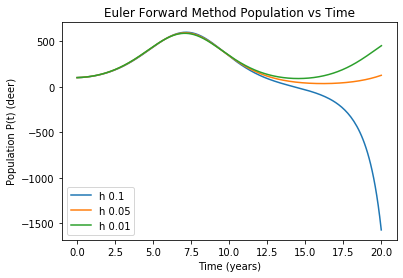

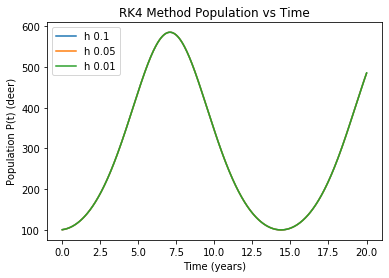

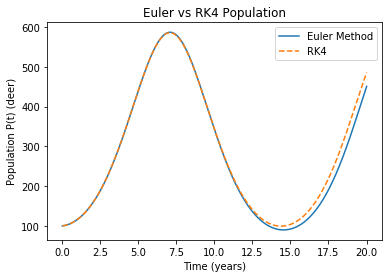

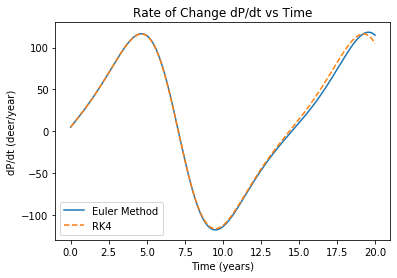

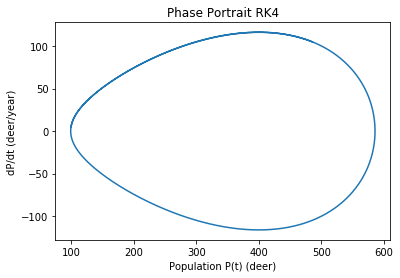

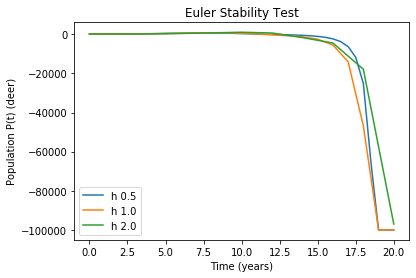

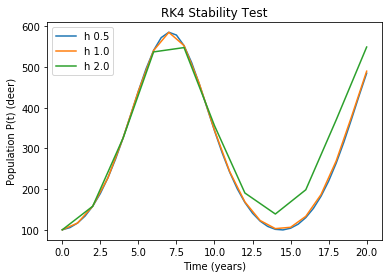

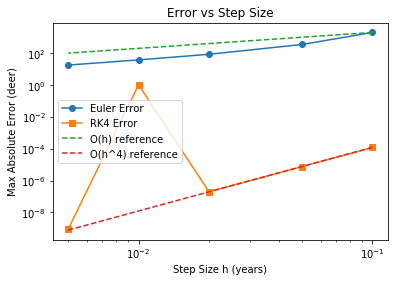

In [3]:
# COE 311K Final Project Part 1
# Option D: Population Dynamics
# System: White-Tailed Deer Population in Texas Hill Country
# Name: Soham Kinkhabwala
# EID: sbk788

import numpy as np
import matplotlib.pyplot as plt

# Parameters
r = 0.3
k = 0.00075

# equilibrium population: P_star = r / k = 400 deer

P0 = 100.0
dP0 = 5.0

t0 = 0.0
tf = 20.0

# ODE right-hand side
def ode_rhs(t, y1, y2):
    return r * y1 - k * y1**2

# Euler Forward Method
def euler_forward(t0, tf, h, y1_0, y2_0):
    t = np.arange(t0, tf + h, h)
    n = len(t)

    y1 = np.zeros(n)
    y2 = np.zeros(n)

    y1[0] = y1_0
    y2[0] = y2_0

    for i in range(n - 1):
        y1[i + 1] = y1[i] + h * y2[i]
        y2[i + 1] = y2[i] + h * ode_rhs(t[i], y1[i], y2[i])

    return t, y1, y2

# RK4 Method
def rk4(t0, tf, h, y1_0, y2_0):
    t = np.arange(t0, tf + h, h)
    n = len(t)

    y1 = np.zeros(n)
    y2 = np.zeros(n)

    y1[0] = y1_0
    y2[0] = y2_0

    for i in range(n - 1):

        k1_1 = y2[i]
        k1_2 = ode_rhs(t[i], y1[i], y2[i])

        k2_1 = y2[i] + (h / 2) * k1_2
        k2_2 = ode_rhs(t[i] + h / 2, y1[i] + (h / 2) * k1_1, y2[i] + (h / 2) * k1_2)

        k3_1 = y2[i] + (h / 2) * k2_2
        k3_2 = ode_rhs(t[i] + h / 2, y1[i] + (h / 2) * k2_1, y2[i] + (h / 2) * k2_2)

        k4_1 = y2[i] + h * k3_2
        k4_2 = ode_rhs(t[i] + h, y1[i] + h * k3_1, y2[i] + h * k3_2)

        y1[i + 1] = y1[i] + (h / 6) * (k1_1 + 2 * k2_1 + 2 * k3_1 + k4_1)

        y2[i + 1] = y2[i] + (h / 6) * (k1_2 + 2 * k2_2 + 2 * k3_2 + k4_2)

    return t, y1, y2

step_sizes = [0.1, 0.05, 0.01]

# Euler population vs time
plt.figure()

for h in step_sizes:
    t, y1, y2 = euler_forward(t0, tf, h, P0, dP0)
    plt.plot(t, y1, label=f'h {h}')

plt.title("Euler Forward Method Population vs Time")
plt.xlabel("Time (years)")
plt.ylabel("Population P(t) (deer)")
plt.legend()
plt.show()

# RK4 population vs time
plt.figure()

for h in step_sizes:
    t, y1, y2 = rk4(t0, tf, h, P0, dP0)
    plt.plot(t, y1, label=f'h {h}')

plt.title("RK4 Method Population vs Time")
plt.xlabel("Time (years)")
plt.ylabel("Population P(t) (deer)")
plt.legend()
plt.show()

# Direct comparison
h = 0.01

t_e, y1_e, y2_e = euler_forward(t0, tf, h, P0, dP0)
t_r, y1_r, y2_r = rk4(t0, tf, h, P0, dP0)

plt.figure()
plt.plot(t_e, y1_e, label="Euler Method")
plt.plot(t_r, y1_r, '--', label="RK4")
plt.title("Euler vs RK4 Population")
plt.xlabel("Time (years)")
plt.ylabel("Population P(t) (deer)")
plt.legend()
plt.show()

# Rate of change comparison
plt.figure()
plt.plot(t_e, y2_e, label="Euler Method")
plt.plot(t_r, y2_r, '--', label="RK4")
plt.title("Rate of Change dP/dt vs Time")
plt.xlabel("Time (years)")
plt.ylabel("dP/dt (deer/year)")
plt.legend()
plt.show()

# Phase portrait
plt.figure()

t_ph, y1_ph, y2_ph = rk4(t0, tf, 0.01, P0, dP0)

plt.plot(y1_ph, y2_ph)
plt.title("Phase Portrait RK4")
plt.xlabel("Population P(t) (deer)")
plt.ylabel("dP/dt (deer/year)")
plt.show()

large_steps = [0.5, 1.0, 2.0]

plt.figure()

for h in large_steps:
    t, y1, y2 = euler_forward(t0, tf, h, P0, dP0)
    y1_plot = np.clip(y1, -1e5, 1e5)
    plt.plot(t, y1_plot, label=f'h {h}')

plt.title("Euler Stability Test")
plt.xlabel("Time (years)")
plt.ylabel("Population P(t) (deer)")
plt.legend()
plt.show()

# RK4 stability test
plt.figure()

for h in large_steps:
    t, y1, y2 = rk4(t0, tf, h, P0, dP0)
    y1_plot = np.clip(y1, -1e5, 1e5)
    plt.plot(t, y1_plot, label=f'h {h}')

plt.title("RK4 Stability Test")
plt.xlabel("Time (years)")
plt.ylabel("Population P(t) (deer)")
plt.legend()
plt.show()

# Error analysis
h_ref = 0.001
t_ref, y1_ref, _ = rk4(t0, tf, h_ref, P0, dP0)

test_steps = [0.1, 0.05, 0.02, 0.01, 0.005]

euler_errors = []
rk4_errors = []

for h in test_steps:

    t_e, y1_e, _ = euler_forward(t0, tf, h, P0, dP0)
    t_r, y1_r, _ = rk4(t0, tf, h, P0, dP0)

    y1_ref_interp_e = np.interp(t_e, t_ref, y1_ref)
    y1_ref_interp_r = np.interp(t_r, t_ref, y1_ref)

    euler_errors.append(np.max(np.abs(y1_e - y1_ref_interp_e)))
    rk4_errors.append(np.max(np.abs(y1_r - y1_ref_interp_r)))

h_arr = np.array(test_steps)

plt.figure()

plt.loglog(h_arr, euler_errors, 'o-', label="Euler Error")
plt.loglog(h_arr, rk4_errors, 's-', label="RK4 Error")

plt.loglog(
    h_arr,
    euler_errors[0] * (h_arr / h_arr[0]),
    '--',
    label="O(h) reference"
)

plt.loglog(
    h_arr,
    rk4_errors[0] * (h_arr / h_arr[0])**4,
    '--',
    label="O(h^4) reference"
)

plt.title("Error vs Step Size")
plt.xlabel("Step Size h (years)")
plt.ylabel("Max Absolute Error (deer)")
plt.legend()
plt.show()